# Simple Exponential Smoothing Forecasting

**Goal:** Determine whether SES outperforms the rolling average baseline (12.42% MAPE).

**Approach:**
1. Load sales data from the database
2. For each product, search for the best alpha (α) using the training window
3. Generate forecasts for the test window (days 84–90)
4. Compare MAPE per product and overall against the baseline

**Backtest split — same as notebook 03:**
- Training: days 1–83
- Test: days 84–90 (7-day horizon)

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker

sns.set_theme(style='whitegrid')

## 1. Load Data

In [3]:
DATABASE_URL = 'sqlite:///../data/forecasting.db'
engine = create_engine(DATABASE_URL)

sales_df = pd.read_sql('SELECT product_id, quantity_sold, sale_date FROM sales', engine)
products_df = pd.read_sql('SELECT product_id, name, category FROM products', engine)

sales_df['sale_date'] = pd.to_datetime(sales_df['sale_date'])
sales_df = sales_df.sort_values(['product_id', 'sale_date']).reset_index(drop=True)

print(f'Sales rows: {len(sales_df)}')
print(f'Products: {len(products_df)}')
sales_df.head()

Sales rows: 1350
Products:   15


,product_id,quantity_sold,sale_date
0,1,54,2024-01-01
1,1,33,2024-01-02
2,1,48,2024-01-03
3,1,51,2024-01-04
4,1,44,2024-01-05


## 2. Define the Backtest Split

Same split as notebook 03 — first 83 days train, last 7 days test.

In [4]:
all_dates = sorted(sales_df['sale_date'].unique())
train_dates = all_dates[:83]
test_dates  = all_dates[83:]

print(f'Train: {train_dates[0].date()} → {train_dates[-1].date()}  ({len(train_dates)} days)')
print(f'Test: {test_dates[0].date()}  → {test_dates[-1].date()}   ({len(test_dates)} days)')

Train: 2024-01-01 → 2024-03-23  (83 days)
Test: 2024-03-24  → 2024-03-30   (7 days)


## 3. Alpha Search

For each product we try a range of alpha values on the **training window only**
and pick the one that minimises in-sample MAE. This is a simple grid search —
no data leakage because the test window is never touched here.

In [5]:
ALPHA_CANDIDATES = np.round(np.arange(0.1, 1.0, 0.05), 2)

best_alphas = {}

for product_id in sales_df['product_id'].unique():
    product_sales = (
        sales_df[sales_df['product_id'] == product_id]
        .set_index('sale_date')['quantity_sold']
    )
    train_series = product_sales[product_sales.index.isin(train_dates)]

    best_mae = float('inf')
    best_alpha = 0.3  # sensible fallback

    for alpha in ALPHA_CANDIDATES:
        model  = SimpleExpSmoothing(train_series).fit(
            smoothing_level=alpha,
            optimized=False
        )
        fitted = model.fittedvalues
        mae = np.mean(np.abs(train_series - fitted))
        if mae < best_mae:
            best_mae   = mae
            best_alpha = alpha

    best_alphas[product_id] = best_alpha

# Display results
alpha_df = (pd.DataFrame.from_dict(best_alphas, orient='index', columns=['best_alpha'])
    .reset_index()
    .rename(columns={'index': 'product_id'})
    .merge(products_df[['product_id', 'name', 'category']], on='product_id')
    .sort_values('best_alpha', ascending=False)
)
print(alpha_df.to_string(index=False))

 product_id  best_alpha           name     category
          7        0.30         Yogurt Refrigerated
         12        0.15         Bleach    Household
         13        0.15   Paper Towels    Household
          3        0.10       Tomatoes   Perishable
          4        0.10        Lettuce   Perishable
          2        0.10         Apples   Perishable
          1        0.10        Bananas   Perishable
          6        0.10     Whole Milk Refrigerated
          5        0.10        Carrots   Perishable
          8        0.10         Butter Refrigerated
          9        0.10   Orange Juice Refrigerated
         11        0.10      Dish Soap    Household
         10        0.10 Cheddar Cheese Refrigerated
         14        0.10        Shampoo    Household
         15        0.10     Toothpaste    Household


**Reading the alpha values:**
- High alpha (close to 1) → product has volatile demand; recent days dominate
- Low alpha (close to 0) → product has stable demand; history matters more

## 4. Generate Test Forecasts

Using each product's best alpha, fit SES on the full training window,
then forecast 7 steps ahead (one per test day).

In [6]:
results = []

for product_id in sales_df['product_id'].unique():
    product_sales = (
        sales_df[sales_df['product_id'] == product_id]
        .set_index('sale_date')['quantity_sold']
    )
    train_series = product_sales[product_sales.index.isin(train_dates)]
    test_series  = product_sales[product_sales.index.isin(test_dates)]

    alpha = best_alphas[product_id]
    model = SimpleExpSmoothing(train_series).fit(
        smoothing_level=alpha,
        optimized=False
    )
    forecast = model.forecast(len(test_dates))

    for date, actual, predicted in zip(test_dates, test_series.values, forecast.values):
        results.append({
            'product_id': product_id,
            'sale_date':  date,
            'actual':     actual,
            'predicted':  predicted,
            'alpha':      alpha,
        })

results_df = pd.DataFrame(results).merge(products_df, on='product_id')
print(f'Forecast rows: {len(results_df)}')
results_df.head(10)

Forecast rows: 105


,product_id,sale_date,actual,predicted,alpha,name,category
0,1,2024-03-24,0,46.831909,0.1,Bananas,Perishable
1,1,2024-03-25,41,46.831909,0.1,Bananas,Perishable
2,1,2024-03-26,21,46.831909,0.1,Bananas,Perishable
3,1,2024-03-27,37,46.831909,0.1,Bananas,Perishable
4,1,2024-03-28,50,46.831909,0.1,Bananas,Perishable
5,1,2024-03-29,40,46.831909,0.1,Bananas,Perishable
6,1,2024-03-30,57,46.831909,0.1,Bananas,Perishable
7,2,2024-03-24,30,32.806553,0.1,Apples,Perishable
8,2,2024-03-25,30,32.806553,0.1,Apples,Perishable
9,2,2024-03-26,24,32.806553,0.1,Apples,Perishable


## 5. Evaluate — MAPE Per Product

In [7]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error. Skips rows where actual == 0."""
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


product_metrics = []

for product_id, group in results_df.groupby('product_id'):
    m = mape(group['actual'].values, group['predicted'].values)
    product_metrics.append({
        'product_id': product_id,
        'name':       group['name'].iloc[0],
        'category':   group['category'].iloc[0],
        'alpha':      group['alpha'].iloc[0],
        'mape':       round(m, 2),
    })

metrics_df = pd.DataFrame(product_metrics).sort_values('mape', ascending=False)

# Baseline values from notebook 03 for direct comparison
baseline = {
    'Bananas': 30.5, 'Lettuce': 25.5, 'Whole Milk': 24.0,
    'Bleach': 0.0,   'Shampoo': 2.0
}
metrics_df['baseline_mape'] = metrics_df['name'].map(baseline)

print(metrics_df.to_string(index=False))

 product_id           name     category  alpha  mape  baseline_mape
         15     Toothpaste    Household   0.10 44.40            NaN
          1        Bananas   Perishable   0.10 34.18           30.5
         11      Dish Soap    Household   0.10 31.06            NaN
          7         Yogurt Refrigerated   0.30 29.83            NaN
         10 Cheddar Cheese Refrigerated   0.10 29.45            NaN
         12         Bleach    Household   0.15 28.77            0.0
         13   Paper Towels    Household   0.15 28.10            NaN
         14        Shampoo    Household   0.10 27.02            2.0
          4        Lettuce   Perishable   0.10 22.76           25.5
          3       Tomatoes   Perishable   0.10 21.69            NaN
          2         Apples   Perishable   0.10 21.02            NaN
          6     Whole Milk Refrigerated   0.10 20.00           24.0
          8         Butter Refrigerated   0.10 19.28            NaN
          5        Carrots   Perishable   0.10 1

## 6. Overall MAPE — SES vs Baseline

In [8]:
overall_mape = mape(results_df['actual'].values, results_df['predicted'].values)
baseline_mape = 12.42

print(f'Baseline MAPE (rolling avg): {baseline_mape:.2f}%')
print(f'SES MAPE: {overall_mape:.2f}%')
print()
if overall_mape < baseline_mape:
    improvement = baseline_mape - overall_mape
    print(f'✓ SES beats the baseline by {improvement:.2f} percentage points.')
else:
    gap = overall_mape - baseline_mape
    print(f'✗ SES does not beat the baseline (worse by {gap:.2f} percentage points).')

Baseline MAPE (rolling avg): 12.42%
SES MAPE:                    26.15%

✗ SES does not beat the baseline (worse by 13.73 percentage points).


## 7. Visualise — Forecast vs Actual (High-Error Products)

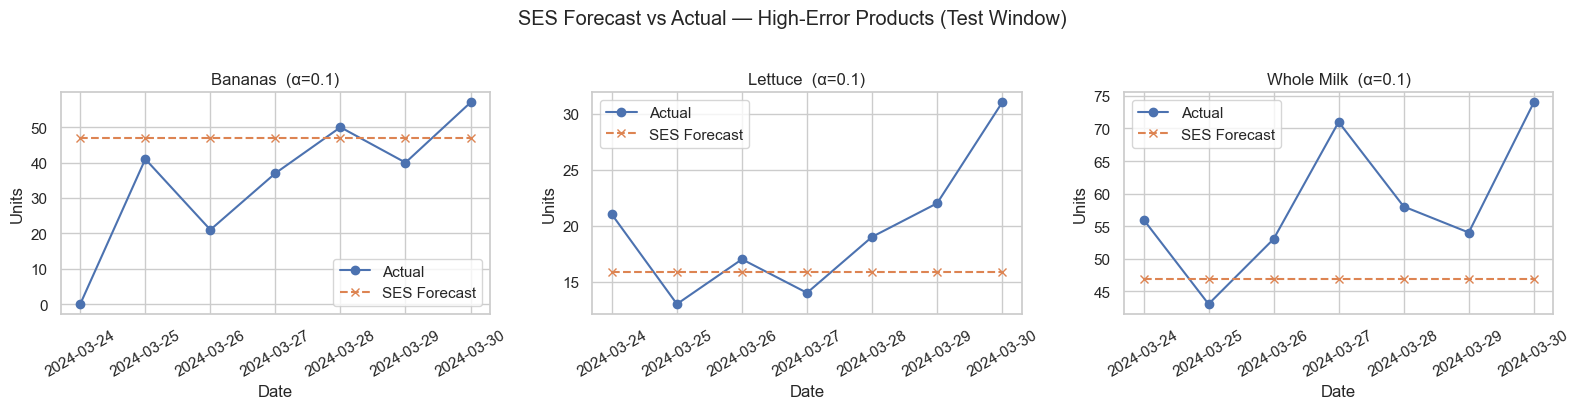

In [9]:
targets = ['Bananas', 'Lettuce', 'Whole Milk']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name in zip(axes, targets):
    subset = results_df[results_df['name'] == name].sort_values('sale_date')
    ax.plot(subset['sale_date'], subset['actual'],    label='Actual',    marker='o')
    ax.plot(subset['sale_date'], subset['predicted'], label='SES Forecast', marker='x', linestyle='--')
    ax.set_title(f'{name}  (α={subset["alpha"].iloc[0]})')
    ax.set_xlabel('Date')
    ax.set_ylabel('Units')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()

plt.suptitle('SES Forecast vs Actual — High-Error Products (Test Window)', y=1.02)
plt.tight_layout()
plt.show()

# Conclusion

### SES lost — and by a significant margin. In theory it should have outperformed the rolling average, but what altered the results is that the synthetic data was generated with Poisson-distributed daily sales around a stable mean, with weekend boosts. There's no real trend or momentum in the data. So a model that chases recent history (SES) gets punished, while a model that averages broadly (rolling average) does better.